In [15]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from locallib.picarrodb import *
from locallib.query import *
import pandas as pd

In [ ]:
a = get_users(customer_name = 'Italgas', user_table = '#TempUser')
b = get_surveys(user_table = '#TempUser', survey_table = '#TempSurvey', start_date = '2026-01-08', end_date = '2026-03-15')
b.set_child(Query(
    query = (
        "SELECT "
        "COUNT(P.Id) AS PeakCount, "
        "P.SurveyId, "
        "SQA.AverageFlowRate "
        "INTO #TempPeak "
        "FROM Peak P "
        "LEFT JOIN SurveyQACheck SQA ON P.SurveyId = SQA.SurveyId "
        "WHERE P.SurveyId IN (SELECT SurveyId FROM #TempSurvey) "
   
        "GROUP BY P.SurveyId, SQA.AverageFlowRate"
    )
))
a.set_child(b)
data = a.execute(EU2_Conn, table_return = ['#TempPeak', '#TempSurvey'])

In [18]:
peak_survey = pd.merge(data['#TempSurvey'][['SurveyId', 'SurveyorUnit','RawDurationMinutes','StartDateTime','EndDateTime']], data['#TempPeak'][['PeakCount', 'SurveyId', 'AverageFlowRate']], on = 'SurveyId', how = 'left')
peak_survey['AverageFlowRate'] = peak_survey['AverageFlowRate'].astype(float)
peak_survey = peak_survey.dropna(subset=['AverageFlowRate'])
peak_survey['PeakMinutes'] = peak_survey['PeakCount'] / peak_survey['RawDurationMinutes']

In [ ]:
peak_survey[peak_survey['SurveyorUnit'].astype(str).str.contains('#48')]

,SurveyId,SurveyorUnit,RawDurationMinutes,StartDateTime,EndDateTime,PeakCount,AverageFlowRate,PeakMinutes
0,941DECED-0C52-1D73-3087-3A1F2C72B327,Car#16 Jeep Renegade GX227TT,77,2026-02-01 17:35:16.767,2026-02-01 18:52:19.113,27.0,4.060898,0.350649
33,18D08135-9F63-3D86-81D2-3A1F2D667807,Car#16 Jeep Renegade GX227TT,79,2026-02-01 22:01:29.683,2026-02-01 23:20:30.350,13.0,4.078957,0.164557
90,49ADB0DF-EB2C-B47B-E375-3A1F32F97327,Car#16 Jeep Renegade GX227TT,25,2026-02-03 00:00:05.927,2026-02-03 00:25:31.793,6.0,3.609160,0.240000
93,96C040FF-A908-08D0-982C-3A1F33111100,Car#16 Jeep Renegade GX227TT,26,2026-02-03 00:26:03.173,2026-02-03 00:52:13.087,1.0,3.478856,0.038462
128,C13E92F6-FA8E-96E0-1088-3A1F37246555,Car#16 Jeep Renegade GX227TT,119,2026-02-03 19:25:34.377,2026-02-03 21:24:36.060,48.0,4.069069,0.403361
...,...,...,...,...,...,...,...,...
14632,EE0E717E-5566-0621-407E-3A20A582D877,Car#16 Jeep Renegade GX227TT,110,2026-04-15 22:49:42.637,2026-04-16 00:39:12.907,43.0,4.013503,0.390909
14701,50BC23FD-9FFE-DA48-66DB-3A1F4B513993,Car#16 Jeep Renegade GX227TT,95,2026-02-07 17:26:56.457,2026-02-07 19:01:05.040,44.0,4.153065,0.463158
14726,16D08B8A-BAAE-2E99-32EA-3A1F4C20A570,Car#16 Jeep Renegade GX227TT,2,2026-02-07 21:13:27.347,2026-02-07 21:15:08.980,1.0,4.064299,0.500000
14738,17C419FD-1FBF-CC1A-CE11-3A1F4C3B4A81,Car#16 Jeep Renegade GX227TT,146,2026-02-07 21:42:36.407,2026-02-08 00:08:31.133,41.0,4.068850,0.280822


In [20]:
peak_survey = peak_survey.sort_values(['SurveyorUnit', 'StartDateTime'])
peak_survey = peak_survey[peak_survey['AverageFlowRate'] > 0]

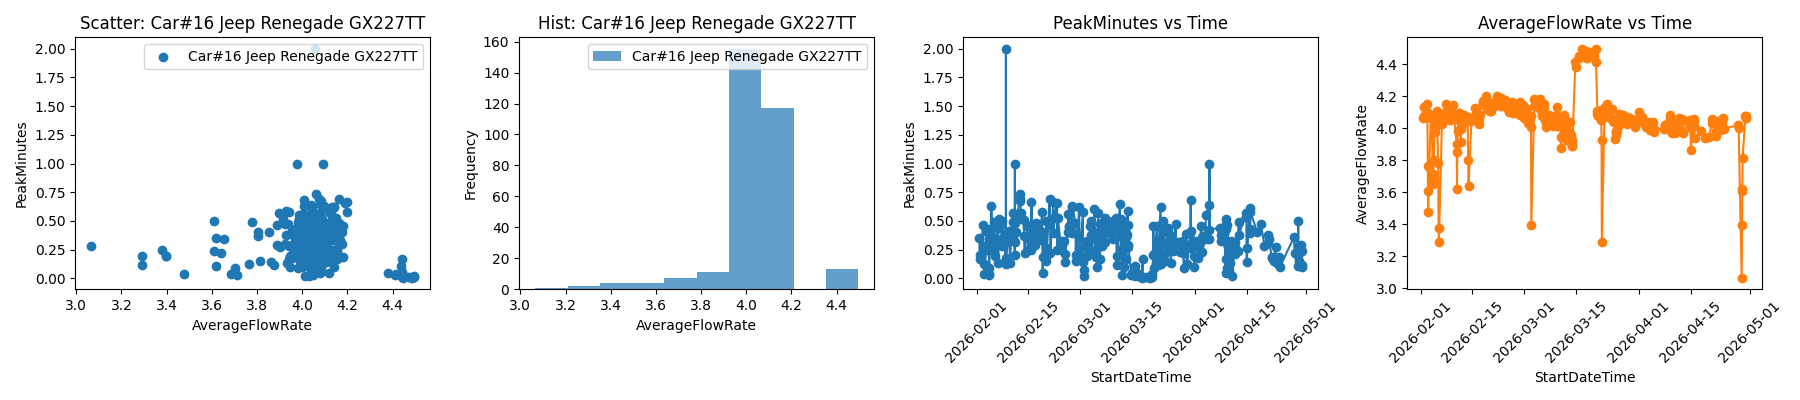

In [21]:
import matplotlib.pyplot as plt

for surveyor_unit in peak_survey.loc[peak_survey['SurveyorUnit'].astype(str).str.contains('#16'), 'SurveyorUnit'].unique():
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit].sort_values('StartDateTime')
    
    # Since some subplots were deleted, change shape (now 1 row, 4 columns)
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    # 1. Scatter: AverageFlowRate vs PeakMinutes
    axs[0].scatter(
        subset['AverageFlowRate'],
        subset['PeakMinutes'],
        label=surveyor_unit
    )
    axs[0].set_title(f"Scatter: {surveyor_unit}")
    axs[0].set_xlabel('AverageFlowRate')
    axs[0].set_ylabel('PeakMinutes')
    axs[0].legend()

    # 2. Histogram of AverageFlowRate
    axs[1].hist(subset['AverageFlowRate'], label=surveyor_unit, alpha=0.7)
    axs[1].set_title(f"Hist: {surveyor_unit}")
    axs[1].set_xlabel('AverageFlowRate')
    axs[1].set_ylabel('Frequency')
    axs[1].legend()

    # 3. Time series: PeakMinutes over time
    axs[2].plot(subset['StartDateTime'], subset['PeakMinutes'], marker='o')
    axs[2].set_xlabel('StartDateTime')
    axs[2].set_ylabel('PeakMinutes')
    axs[2].set_title(f"PeakMinutes vs Time")
    axs[2].tick_params(axis='x', rotation=45)
    
    # 4. Time series: AverageFlowRate over time
    axs[3].plot(subset['StartDateTime'], subset['AverageFlowRate'], marker='o', color='tab:orange')
    axs[3].set_xlabel('StartDateTime')
    axs[3].set_ylabel('AverageFlowRate')
    axs[3].set_title(f"AverageFlowRate vs Time")
    axs[3].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [25]:
peak_survey.loc[peak_survey['SurveyorUnit'].astype(str).str.contains('#16'), 'SurveyorUnit'].unique()

array(['Car#16 Jeep Renegade GX227TT'], dtype=object)

/tmp/ipykernel_9421/2719439262.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


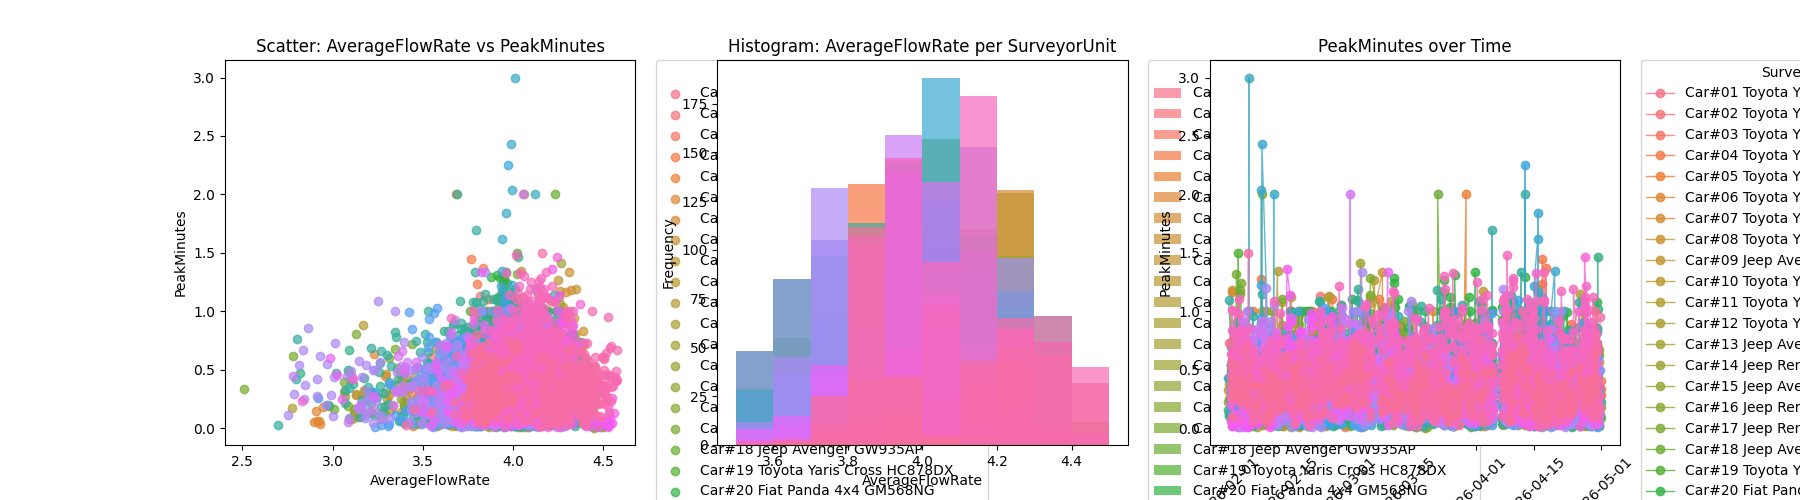

In [22]:
import matplotlib.pyplot as plt

# Assign a color to each unique SurveyorUnit
import seaborn as sns
color_palette = sns.color_palette("husl", len(peak_survey['SurveyorUnit'].unique()))
surveyor_units = peak_survey['SurveyorUnit'].unique()
color_map = dict(zip(surveyor_units, color_palette))

import numpy as np

# Create three plots: scatter, histogram, and time series
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter: AverageFlowRate vs PeakMinutes for all SurveyorUnits
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit]
    ax1.scatter(
        subset['AverageFlowRate'],
        subset['PeakMinutes'],
        color=color_map[surveyor_unit],
        label=surveyor_unit,
        alpha=0.7
    )
ax1.set_xlabel('AverageFlowRate')
ax1.set_ylabel('PeakMinutes')
ax1.set_title('Scatter: AverageFlowRate vs PeakMinutes')
ax1.legend(title='SurveyorUnit', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# 2. Overlaid histogram for AverageFlowRate for all SurveyorUnits
bins = np.arange(3.5, 4.5 + 0.01, 0.1)  # step size of 0.1 (adjust as needed)
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit]
    ax2.hist(
        subset['AverageFlowRate'].astype(float),
        bins=bins,
        alpha=0.7,
        label=surveyor_unit,
        color=color_map[surveyor_unit]
    )
ax2.set_title("Histogram: AverageFlowRate per SurveyorUnit")
ax2.set_xlabel('AverageFlowRate')
ax2.set_ylabel('Frequency')
ax2.legend(title='SurveyorUnit', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# 3. Time plot: PeakMinutes over StartDateTime for all SurveyorUnits
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit].sort_values('StartDateTime')
    ax3.plot(
        subset['StartDateTime'],
        subset['PeakMinutes'],
        marker='o',
        label=surveyor_unit,
        color=color_map[surveyor_unit],
        alpha=0.8,
        linewidth=1
    )
ax3.set_xlabel('StartDateTime')
ax3.set_ylabel('PeakMinutes')
ax3.set_title('PeakMinutes over Time')
ax3.legend(title='SurveyorUnit', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
peak_survey

,SurveyId,SurveyorUnit,RawDurationMinutes,StartDateTime,EndDateTime,PeakCount,AverageFlowRate,PeakMinutes
1,B197D2BB-A4B0-8FEE-A15B-3A1F2C767C4B,Car#01 Toyota Yaris Cross HC999DW,97,2026-02-01 17:39:37.710,2026-02-01 19:16:24.827,49.0,4.425939,0.505155
615,A09917DC-587E-28B3-79D9-3A1F2CEC4F5D,Car#01 Toyota Yaris Cross HC999DW,92,2026-02-01 19:48:04.973,2026-02-01 21:20:07.900,29.0,4.367227,0.315217
2536,52AE1F6D-8140-19AC-63EC-3A1F2D40E74F,Car#01 Toyota Yaris Cross HC999DW,36,2026-02-01 21:20:37.520,2026-02-01 21:56:42.157,16.0,4.332005,0.444444
41,804B8997-005C-3A05-C85D-3A1F2D74E45F,Car#01 Toyota Yaris Cross HC999DW,94,2026-02-01 22:17:15.547,2026-02-01 23:51:41.417,28.0,4.285185,0.297872
2563,B68AD488-9C09-F69F-A47B-3A1F319B826F,Car#01 Toyota Yaris Cross HC999DW,118,2026-02-02 17:38:07.440,2026-02-02 19:36:49.387,34.0,4.372158,0.288136
...,...,...,...,...,...,...,...,...
14399,7D178E61-3F8B-8560-D030-3A20EA735507,Car#55 2i Rete Jeep Avenger GW968ZG,184,2026-04-29 08:06:35.217,2026-04-29 11:10:30.567,78.0,3.820637,0.423913
13354,C835C33A-D578-542D-9E01-3A20EB1FCEBC,Car#55 2i Rete Jeep Avenger GW968ZG,39,2026-04-29 11:14:56.147,2026-04-29 11:53:26.390,39.0,3.779444,1.000000
13364,64EDEEA0-08D3-1252-DAA5-3A20EB65A6CA,Car#55 2i Rete Jeep Avenger GW968ZG,6,2026-04-29 12:31:13.577,2026-04-29 12:37:54.327,2.0,3.765606,0.333333
14507,F925BE47-5C76-C00E-703B-3A20ECA69148,Car#55 2i Rete Jeep Avenger GW968ZG,200,2026-04-29 18:21:46.827,2026-04-29 21:41:56.513,129.0,3.829950,0.645000
